# 1. 读取上一步标记的细胞

前面已经对CID4471、CID4067和CID4535做了QC，这里展开CAF、CD8 T和PVL的复核记录，并一起查看内皮群及CID4535低计数癌上皮。

每个细胞保留原条码、作者三级标签和各项QC标记，后续把marker计数和处理记录加在同一张表中。

In [1]:
from pathlib import Path
import json
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_dir = Path("/Users/georicl/Documents/sc_sncell_github")
qc_dir = project_dir / "results/Wu2021_ER_donor_qc_v1"
object_dir = project_dir / "data/processed/Wu2021_ER_donor_qc_v1"
result_dir = project_dir / "results/Wu2021_ER_target_review_v1"
result_dir.mkdir(parents=True, exist_ok=True)
donors = ["CID4471", "CID4067", "CID4535"]
targets = ["CAFs", "T cells CD8+", "PVL"]
qc = pd.read_csv(qc_dir / "cell_qc_records.csv", index_col=0)
objects = {
    d: ad.read_h5ad(object_dir / f"{d}_counts_after_qc.h5ad")
    for d in donors
}
target_mask = qc.reference_label.isin(targets)
context_mask = qc.reference_label.eq("Endothelial") | (
    qc.donor_id.eq("CID4535") & qc.reference_label.eq("Cancer Epithelial")
)
review_mask = (target_mask | context_mask) & qc.review_any
display(qc.loc[target_mask].groupby(["donor_id", "reference_label"]).agg(
    total_cells=("review_any", "size"), flagged_cells=("review_any", "sum")
))


total_cells  flagged_cells
donor_id reference_label                            
CID4067  CAFs                     135             10
         PVL                       83             11
         T cells CD8+             243              9
CID4471  CAFs                    1292             23
         PVL                     1285             71
         T cells CD8+             159              3
CID4535  CAFs                     102             20
         PVL                      592            136
         T cells CD8+              98             20

# 2. 展开谱系marker的原始计数

上皮面板使用EPCAM和KRT8/18/19，T细胞面板使用CD3D、CD3E和TRAC，另外单独查看CD8A/B。CAF使用COL1A1/2、DCN和LUM；PVL使用RGS5、CSPG4和MCAM，内皮表达用PECAM1和VWF一起查看。

分别保存每个基因的原始计数、每个面板的总UMI及其占细胞总UMI的比例。组间表达图使用每细胞10000归一化并log1p后的值。

In [2]:
panels = {
    "epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "T_lineage": ["CD3D", "CD3E", "TRAC"],
    "CD8": ["CD8A", "CD8B"],
    "CAF": ["COL1A1", "COL1A2", "DCN", "LUM"],
    "PVL": ["RGS5", "CSPG4", "MCAM"],
    "endothelial": ["PECAM1", "VWF"],
}
genes = list(dict.fromkeys(sum(panels.values(), [])))
parts = []
for donor, a in objects.items():
    parts.append(pd.DataFrame(
        a[:, genes].X.toarray(), index=a.obs_names, columns=genes
    ))
marker_counts = pd.concat(parts).loc[qc.index]
review = qc.copy()
for name, panel_genes in panels.items():
    review[f"{name}_umi"] = marker_counts[panel_genes].sum(axis=1)
    review[f"{name}_pct_umi"] = review[f"{name}_umi"] / review.total_counts * 100
    review[f"{name}_detected_genes"] = marker_counts[panel_genes].gt(0).sum(axis=1)
log_expression = np.log1p(marker_counts.div(review.total_counts, axis=0) * 10000)
marker_counts.loc[review_mask].to_csv(result_dir / "flagged_cell_marker_counts.csv")
review.loc[review_mask].join(marker_counts.add_prefix("count_")).to_csv(
    result_dir / "flagged_cells_detail.csv"
)
display(review.loc[review.review_epithelial_T, [
    "donor_id", "reference_label", "total_counts",
    "epithelial_umi", "epithelial_pct_umi", "T_lineage_umi",
    "T_lineage_pct_umi", "CD8_umi"
]])


,donor_id,reference_label,total_counts,epithelial_umi,epithelial_pct_umi,T_lineage_umi,T_lineage_pct_umi,CD8_umi
barcode,,,,,,,,
CID4471_GGGCACTTCCACGTGG,CID4471,Normal Epithelial,14446,106,0.733767,7,0.048456,0
CID4535_TTTATGCGTGGCGAAT,CID4535,T cells CD8+,4109,4,0.097347,5,0.121684,0
CID4535_TGCCCATCATTGCGGC,CID4535,T cells CD8+,1737,5,0.287853,10,0.575705,4
CID4535_CCTTACGAGACAAGCC,CID4535,T cells CD4+,6259,5,0.079885,22,0.351494,0
CID4535_CATCCACAGGCATGTG,CID4535,Cycling T-cells,9538,4,0.041938,29,0.304047,0
CID4535_ATCTGCCAGGCAATTA,CID4535,Cancer Epithelial,21384,133,0.621960,11,0.051440,4
CID4535_GCTGCGACACGAAGCA,CID4535,Cancer Epithelial,31254,185,0.591924,14,0.044794,3


# 3. 比较带标记细胞与同类其他细胞

同一个供者和细胞类型内，分别统计带标记细胞及其他细胞的QC中位数和marker检测情况。查看低计数与谱系表达的关系，也查看MAD高线粒体标记对应的实际比例。

In [3]:
review["review_group"] = np.where(review.review_any, "flagged", "other")
group_columns = ["donor_id", "reference_label", "review_group"]
group_keys = [review[c] for c in group_columns]
group_qc = review.loc[target_mask | context_mask].groupby(group_columns).agg(
    n_cells=("total_counts", "size"),
    umi_median=("total_counts", "median"),
    genes_median=("n_genes_by_counts", "median"),
    mt_median=("pct_counts_mt", "median"),
    mt_max=("pct_counts_mt", "max"),
)
means = log_expression.groupby(group_keys).mean()
detected = marker_counts.gt(0).groupby(group_keys).mean()
group_qc.to_csv(result_dir / "flagged_vs_other_qc.csv")
means.to_csv(result_dir / "flagged_vs_other_marker_mean.csv")
detected.to_csv(result_dir / "flagged_vs_other_marker_detection.csv")
display(group_qc)

flag_columns = [c for c in review if c.startswith("review_") and c not in ["review_any", "review_group"]]
flag_rows = []
for (donor, label), group in review.loc[target_mask | context_mask].groupby(["donor_id", "reference_label"]):
    for flag in flag_columns:
        marked = group.loc[group[flag]]
        if len(marked):
            flag_rows.append({
                "donor_id": donor, "reference_label": label, "flag": flag,
                "n_cells": len(marked),
                "umi_min": marked.total_counts.min(),
                "umi_median": marked.total_counts.median(),
                "umi_max": marked.total_counts.max(),
                "mt_min": marked.pct_counts_mt.min(),
                "mt_median": marked.pct_counts_mt.median(),
                "mt_max": marked.pct_counts_mt.max(),
            })
flag_details = pd.DataFrame(flag_rows)
flag_details.to_csv(result_dir / "flag_numeric_ranges.csv", index=False)
display(flag_details[flag_details.flag.eq("review_high_mt")])


n_cells  umi_median  genes_median  \
donor_id reference_label   review_group                                      
CID4067  CAFs              flagged            10       989.5         578.0   
                           other             125      4215.0        1651.0   
         Endothelial       flagged             8      1252.0         613.0   
                           other             178      1571.5         834.5   
         PVL               flagged            11      2537.0        1224.0   
                           other              72      1323.0         695.0   
         T cells CD8+      flagged             9       574.0         355.0   
                           other             234       993.5         526.0   
CID4471  CAFs              flagged            23      3292.0        1354.0   
                           other            1269      4638.0        1772.0   
         Endothelial       flagged           141      4599.0        1676.0   
                           other            2637      6196.0        2159.0   
         PVL               flagged            71      5346.0        1915.0   
                           other            1214      3787.5        1475.0   
         T cells CD8+      flagged             3       366.0         254.0   
                           other             156      2174.5         981.0   
CID4535  CAFs              flagged            20      3918.5        1397.5   
                           other              82      4878.5        1652.0   
         Cancer Epithelial flagged           268      1634.5         717.0   
                           other            1955     22380.0        4095.0   
         Endothelial       flagged            18      2248.0         927.5   
                           other             201      5088.0        1981.0   
         PVL               flagged           136      6703.5        2099.5   
                           other             456      4893.5        1730.0   
         T cells CD8+      flagged            20      1559.0         721.5   
                           other              78      2965.0        1107.0   

                                         mt_median     mt_max  
donor_id reference_label   review_group                        
CID4067  CAFs              flagged        8.940987  12.226067  
                           other          2.595564   7.857581  
         Endothelial       flagged       11.958565  18.843844  
                           other          3.666096  11.099253  
         PVL               flagged        6.727677  19.700748  
                           other          4.725924  12.643678  
         T cells CD8+      flagged       10.540184  13.353116  
                           other          3.239574   8.394458  
CID4471  CAFs              flagged       18.020595  19.805589  
                           other          6.832298  16.657027  
         Endothelial       flagged       16.142295  19.924635  
                           other          7.106188  15.424716  
         PVL               flagged        8.750245  19.902405  
                           other          8.062195  15.867945  
         T cells CD8+      flagged        7.142857   7.650273  
                           other          7.344672  12.721490  
CID4535  CAFs              flagged       12.980690  18.979652  
                           other          3.471612  10.857143  
         Cancer Epithelial flagged        3.476234  19.902913  
                           other          9.038462  19.982602  
         Endothelial       flagged       14.917621  19.596413  
                           other          3.628353  10.512397  
         PVL               flagged        4.804658  18.876904  
                           other          3.781945   8.209765  
         T cells CD8+      flagged       10.695025  18.105079  
                           other          3.529275   8.010942

,donor_id,reference_label,flag,n_cells,umi_min,umi_median,umi_max,mt_min,mt_median,mt_max
2,CID4067,CAFs,review_high_mt,8,358,1364.0,9441,8.303249,9.132046,12.226067
4,CID4067,Endothelial,review_high_mt,7,296,1208.0,1332,11.317568,12.162162,18.843844
6,CID4067,PVL,review_high_mt,3,401,767.0,1432,14.385475,18.774446,19.700748
10,CID4067,T cells CD8+,review_high_mt,8,337,578.5,1270,8.503937,10.647451,13.353116
11,CID4471,CAFs,review_high_mt,20,1092,2830.5,8684,16.778917,18.131280,19.805589
16,CID4471,Endothelial,review_high_mt,95,872,3284.0,8478,15.514057,17.101449,19.924635
22,CID4471,PVL,review_high_mt,19,1601,4681.0,10167,16.280753,18.134947,19.902405
26,CID4535,CAFs,review_high_mt,15,405,2021.0,13662,11.872910,13.397129,18.979652
32,CID4535,Endothelial,review_high_mt,18,1105,2248.0,11875,11.019930,14.917621,19.596413
36,CID4535,PVL,review_high_mt,56,1217,4918.5,17338,8.674249,11.916023,18.876904


# 4. 绘图查看分布与表达

散点图中横轴为log10 UMI，纵轴为线粒体比例，橙色表示带复核标记的细胞。表达图以全部参考类型中的每个基因最大平均表达作缩放，再展示CAF、CD8和PVL，分别比较带标记细胞和其他细胞。

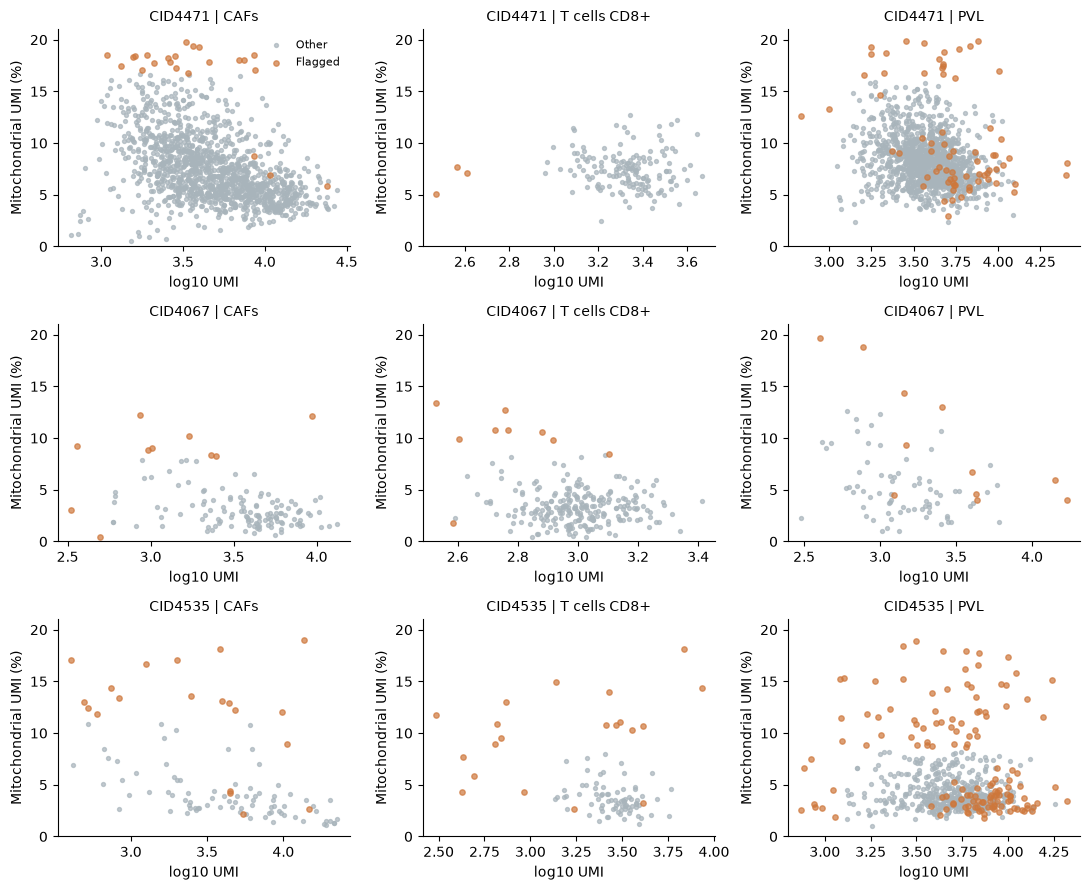

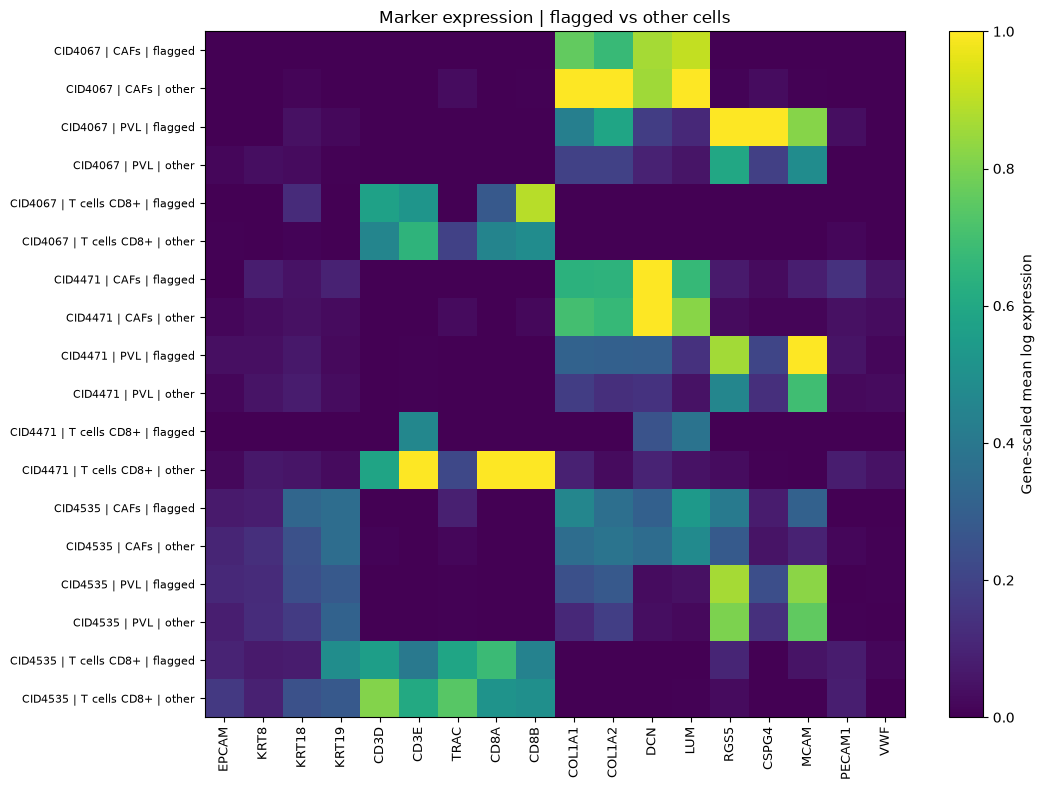

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(11, 9))
for i, donor in enumerate(donors):
    for j, label in enumerate(targets):
        ax = axes[i, j]
        group = review[review.donor_id.eq(donor) & review.reference_label.eq(label)]
        for flagged, color, size in [(False, "#a8b4bb", 8), (True, "#ce773b", 15)]:
            sub = group[group.review_any.eq(flagged)]
            ax.scatter(np.log10(sub.total_counts), sub.pct_counts_mt,
                       color=color, s=size, alpha=0.7,
                       label="Flagged" if flagged else "Other")
        ax.set_title(f"{donor} | {label}", fontsize=10)
        ax.set_xlabel("log10 UMI")
        ax.set_ylabel("Mitochondrial UMI (%)")
        ax.set_ylim(0, 21)
        ax.spines[["top", "right"]].set_visible(False)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(result_dir / "target_qc_review.png", dpi=300)
fig.savefig(result_dir / "target_qc_review.pdf")
plt.show()

target_means = means.loc[
    means.index.get_level_values("reference_label").isin(targets)
]
scaled = target_means.div(means.max(axis=0).replace(0, 1), axis=1)
fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(scaled, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax.set_yticks(range(len(scaled)), [" | ".join(idx) for idx in scaled.index], fontsize=8)
ax.set_xticks(range(len(genes)), genes, rotation=90, fontsize=9)
ax.set_title("Marker expression | flagged vs other cells")
fig.colorbar(im, ax=ax, label="Gene-scaled mean log expression")
fig.tight_layout()
fig.savefig(result_dir / "target_marker_review.png", dpi=300)
fig.savefig(result_dir / "target_marker_review.pdf")
plt.show()


# 5. 记录本轮处理

本轮对照实际UMI、线粒体比例和面板表达，保留作者细胞及注释。MAD标记记录同类分布的相对位置；共同表达面板的逐基因计数保存在复核表中。每个目标细胞都写入处理状态和对应标记，参考使用前可以按条码追溯。

低计数细胞记录为low_depth，高线粒体标记记录为relative_mt_tail，共同表达记录为panel_coexpression，便于后续按同一规则分组查看。

In [5]:
def review_reason(row):
    reasons = []
    if row["review_low_umi"] or row["review_low_genes"]:
        reasons.append("low_depth")
    if row["review_high_mt"]:
        reasons.append("relative_mt_tail")
    if row["review_high_umi"] or row["review_high_genes"]:
        reasons.append("high_depth")
    if row["review_epithelial_T"] or row["review_CAF_PVL"]:
        reasons.append("panel_coexpression")
    return ";".join(reasons) if reasons else "no_review_flag"

decisions = review.loc[target_mask | context_mask].copy()
decisions["review_reason"] = decisions.apply(review_reason, axis=1)
decisions["review_action"] = "retain_author_cell"
decisions["exclude_after_review"] = False
decisions["reviewed_stage"] = "qc_values_and_marker_panels"
decisions.to_csv(result_dir / "cell_review_decisions.csv")

summary = decisions.groupby(["donor_id", "reference_label"]).agg(
    before_review=("review_action", "size"),
    flagged=("review_any", "sum"),
    excluded=("exclude_after_review", "sum"),
)
summary["after_review"] = summary.before_review - summary.excluded
summary.to_csv(result_dir / "reference_counts_after_review.csv")
display(summary)

# 为三个目标类型保存明确的逐细胞使用表
use_table = decisions[decisions.reference_label.isin(targets)][[
    "donor_id", "reference_label", "celltype_minor", "celltype_subset",
    "review_any", "review_reason", "review_action", "exclude_after_review"
]]
use_table.to_csv(result_dir / "target_cell_use_table.csv")

record = {
    "donors": donors, "target_types": targets,
    "n_target_cells": int(target_mask.sum()),
    "n_flagged_target_cells": int((target_mask & review.review_any).sum()),
    "additional_excluded_cells": 0,
    "cell_action": "retain author cells; preserve QC and marker review notes",
    "source_qc": str((qc_dir / "cell_qc_records.csv").relative_to(project_dir)),
    "panels": panels,
}
(result_dir / "review_parameters.json").write_text(
    json.dumps(record, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("保存目录：", result_dir)


before_review  flagged  excluded  after_review
donor_id reference_label                                                  
CID4067  CAFs                         135       10         0           135
         Endothelial                  186        8         0           186
         PVL                           83       11         0            83
         T cells CD8+                 243        9         0           243
CID4471  CAFs                        1292       23         0          1292
         Endothelial                 2778      141         0          2778
         PVL                         1285       71         0          1285
         T cells CD8+                 159        3         0           159
CID4535  CAFs                         102       20         0           102
         Cancer Epithelial           2223      268         0          2223
         Endothelial                  219       18         0           219
         PVL                          592      136         0           592
         T cells CD8+                  98       20         0            98

保存目录： /Users/georicl/Documents/sc_sncell_github/results/Wu2021_ER_target_review_v1
